In [ ]:
from google.colab import files

uploaded = files.upload()

Saving archive (1).zip to archive (1).zip


In [ ]:
import zipfile

with zipfile.ZipFile('archive.zip', 'r') as zip_ref:
    zip_ref.extractall()

print("Extracted Successfully!")

FileNotFoundError: [Errno 2] No such file or directory: 'archive.zip'

In [ ]:
import os

print(os.listdir())

['.config', 'archive (1).zip', 'sample_data']


In [ ]:
import zipfile

with zipfile.ZipFile('archive (1).zip', 'r') as zip_ref:
    zip_ref.extractall()

print("Extracted Successfully!")

Extracted Successfully!


In [ ]:
import os

print(os.listdir())

['.config', 'Mall_Customers.csv', 'archive (1).zip', 'sample_data']


In [ ]:
import pandas as pd

df = pd.read_csv('Mall_Customers.csv')

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [ ]:
print(df.shape)
print(df.columns)

(200, 5)
Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')


In [ ]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

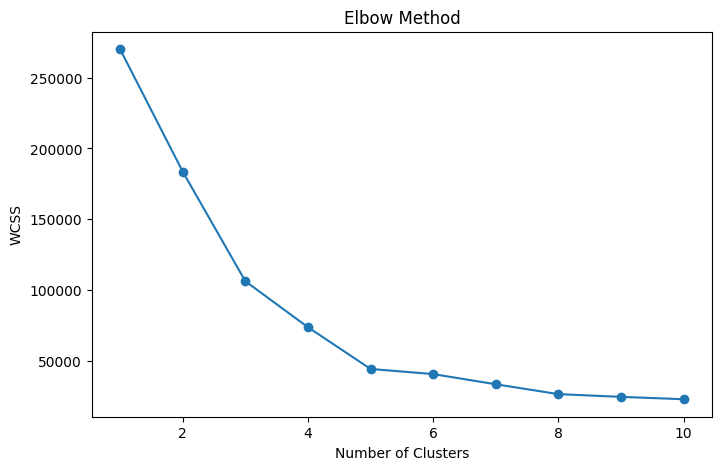

In [ ]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

wcss = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i,
                    init='k-means++',
                    random_state=42)

    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

In [ ]:
kmeans = KMeans(
    n_clusters=5,
    init='k-means++',
    random_state=42
)

y_kmeans = kmeans.fit_predict(X)

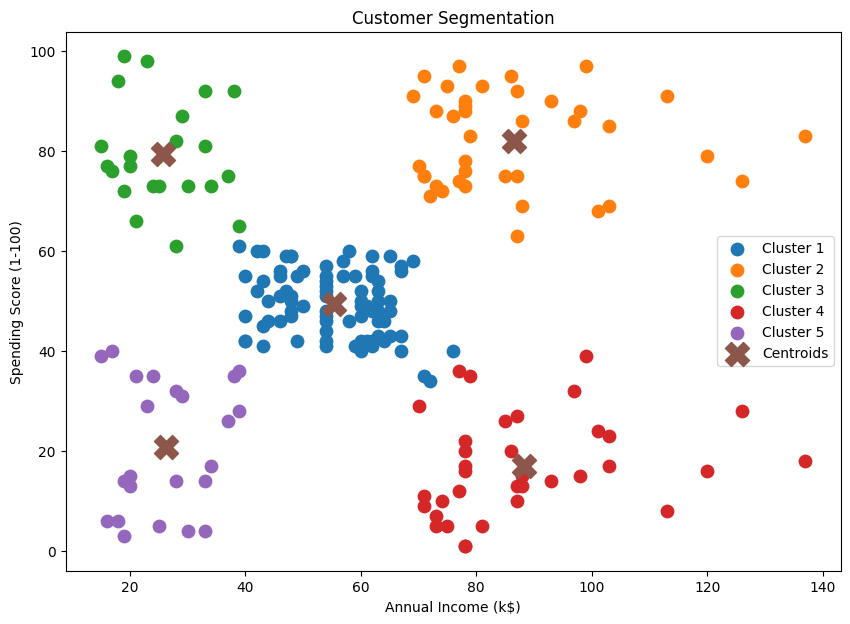

In [ ]:
plt.figure(figsize=(10,7))

plt.scatter(X.iloc[y_kmeans==0,0],
            X.iloc[y_kmeans==0,1],
            s=80,
            label='Cluster 1')

plt.scatter(X.iloc[y_kmeans==1,0],
            X.iloc[y_kmeans==1,1],
            s=80,
            label='Cluster 2')

plt.scatter(X.iloc[y_kmeans==2,0],
            X.iloc[y_kmeans==2,1],
            s=80,
            label='Cluster 3')

plt.scatter(X.iloc[y_kmeans==3,0],
            X.iloc[y_kmeans==3,1],
            s=80,
            label='Cluster 4')

plt.scatter(X.iloc[y_kmeans==4,0],
            X.iloc[y_kmeans==4,1],
            s=80,
            label='Cluster 5')

plt.scatter(
    kmeans.cluster_centers_[:,0],
    kmeans.cluster_centers_[:,1],
    s=300,
    marker='X',
    label='Centroids'
)

plt.title('Customer Segmentation')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.show()